In [5]:
# ============================================================================
# COMPLETE ENGLISH-TO-URDU MACHINE TRANSLATION SOLUTION
# Part 1: Custom Transformer (From Scratch)
# Part 2: Pre-trained mBART Fine-tuning
# Part 3: Comparative Analysis
# ============================================================================

# ============================================================================
# CELL 0: Environment Setup
# ============================================================================

import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

print("="*70)
print("ENGLISH-TO-URDU TRANSLATION: DUAL APPROACH")
print("="*70)
print("Approach 1: Custom Transformer (From Scratch)")
print("Approach 2: Pre-trained mBART Fine-tuning")
print("="*70)

ENGLISH-TO-URDU TRANSLATION: DUAL APPROACH
Approach 1: Custom Transformer (From Scratch)
Approach 2: Pre-trained mBART Fine-tuning


In [6]:
# ============================================================================
# CELL 1: Install Required Libraries
# ============================================================================

!pip install -q torch torchvision torchaudio
!pip install -q transformers datasets
!pip install -q sentencepiece sacremoses
!pip install -q sacrebleu nltk
!pip install -q pandas numpy matplotlib seaborn
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.3 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed

In [7]:
# ============================================================================
# CELL 2: Import Libraries
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.parallel import DataParallel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
import math
import warnings
warnings.filterwarnings('ignore')

# Transformers
from transformers import (
    MBartForConditionalGeneration, 
    MBart50TokenizerFast,
    get_linear_schedule_with_warmup
)
import sacrebleu
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

# Set seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0

print(f"\n{'='*70}")
print(f"SYSTEM CONFIGURATION")
print(f"{'='*70}")
print(f"Device: {device}")
print(f"Number of GPUs: {n_gpus}")
if n_gpus > 0:
    for i in range(n_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"    Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.2f} GB")
print(f"{'='*70}\n")


SYSTEM CONFIGURATION
Device: cuda
Number of GPUs: 2
  GPU 0: Tesla T4
    Memory: 14.74 GB
  GPU 1: Tesla T4
    Memory: 14.74 GB



In [8]:
# ============================================================================
# CELL 3: Load Dataset
# ============================================================================

def load_parallel_corpus_from_txt(english_file, urdu_file):
    """Load English-Urdu parallel corpus from text files"""
    try:
        with open(english_file, 'r', encoding='utf-8') as f:
            english_sentences = f.readlines()
        
        with open(urdu_file, 'r', encoding='utf-8') as f:
            urdu_sentences = f.readlines()
        
        if len(english_sentences) != len(urdu_sentences):
            min_len = min(len(english_sentences), len(urdu_sentences))
            english_sentences = english_sentences[:min_len]
            urdu_sentences = urdu_sentences[:min_len]
        
        df = pd.DataFrame({
            'english': [sent.strip() for sent in english_sentences],
            'urdu': [sent.strip() for sent in urdu_sentences]
        })
        
        print(f"✓ Dataset loaded: {len(df)} parallel sentences")
        return df
        
    except FileNotFoundError:
        print("Dataset files not found. Creating sample dataset...")
        sample_data = {
            'english': [
                'Hello, how are you?', 'What is your name?', 'I am learning translation.',
                'This is a beautiful day.', 'Thank you very much.', 'Good morning.',
                'I love programming.', 'Machine learning is fascinating.', 'The weather is nice.',
                'How can I help you?', 'Where are you from?', 'What time is it?',
                'I like this book.', 'Please help me.', 'Have a nice day.',
                'See you tomorrow.', 'I am happy.', 'This is very good.',
                'Can you speak English?', 'I understand.'
            ] * 50,  # Repeat to get ~1000 samples
            'urdu': [
                'ہیلو، آپ کیسے ہیں؟', 'آپ کا نام کیا ہے؟', 'میں ترجمہ سیکھ رہا ہوں۔',
                'یہ ایک خوبصورت دن ہے۔', 'بہت شکریہ۔', 'صبح بخیر۔',
                'مجھے پروگرامنگ پسند ہے۔', 'مشین لرننگ دلچسپ ہے۔', 'موسم اچھا ہے۔',
                'میں آپ کی کیسے مدد کر سکتا ہوں؟', 'آپ کہاں سے ہیں؟', 'کیا وقت ہوا ہے؟',
                'مجھے یہ کتاب پسند ہے۔', 'براہ کرم میری مدد کریں۔', 'اچھا دن گزاریں۔',
                'کل ملیں گے۔', 'میں خوش ہوں۔', 'یہ بہت اچھا ہے۔',
                'کیا آپ انگریزی بول سکتے ہیں؟', 'میں سمجھتا ہوں۔'
            ] * 50
        }
        df = pd.DataFrame(sample_data)
        return df

# Load dataset
DATASET_PATH = '/kaggle/input/parallel-corpus-for-english-urdu-language'
ENGLISH_CORPUS = '/kaggle/input/parallel-corpus-for-english-urdu-language/Dataset/english-corpus.txt'
URDU_CORPUS = '/kaggle/input/parallel-corpus-for-english-urdu-language/Dataset/urdu-corpus.txt'

df = load_parallel_corpus_from_txt(ENGLISH_CORPUS, URDU_CORPUS)

✓ Dataset loaded: 24525 parallel sentences


In [9]:
# ============================================================================
# CELL 4: Data Preprocessing
# ============================================================================

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = ' '.join(text.split())
    return text

def preprocess_dataframe(df):
    df['english'] = df['english'].apply(clean_text)
    df['urdu'] = df['urdu'].apply(clean_text)
    df = df[(df['english'] != '') & (df['urdu'] != '')]
    df = df.drop_duplicates(subset=['english', 'urdu'])
    df = df[(df['english'].str.len() > 3) & (df['english'].str.len() < 200)]
    df = df[(df['urdu'].str.len() > 3) & (df['urdu'].str.len() < 200)]
    df = df.reset_index(drop=True)
    print(f"After preprocessing: {len(df)} sentences")
    return df

df = preprocess_dataframe(df)

After preprocessing: 24125 sentences


In [10]:
# ============================================================================
# CELL 5: Train-Val-Test Split
# ============================================================================

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

print(f"\nDataset split:")
print(f"Training: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")

# ============================================================================
# PART 1: CUSTOM TRANSFORMER FROM SCRATCH
# ============================================================================

print("\n" + "="*70)
print("PART 1: CUSTOM TRANSFORMER IMPLEMENTATION")
print("="*70)


Dataset split:
Training: 19300
Validation: 2412
Test: 2413

PART 1: CUSTOM TRANSFORMER IMPLEMENTATION


In [11]:
# ============================================================================
# CELL 6: Build Vocabulary for Custom Transformer
# ============================================================================

class Vocabulary:
    """Build vocabulary for source and target languages"""
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        
    def build_vocabulary(self, sentence_list):
        """Build vocabulary from list of sentences"""
        frequencies = {}
        idx = 4
        
        for sentence in sentence_list:
            for word in sentence.split():
                if word not in frequencies:
                    frequencies[word] = 1
                else:
                    frequencies[word] += 1
                
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1
    
    def numericalize(self, text):
        """Convert text to indices"""
        tokenized = text.split()
        return [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokenized]
    
    def __len__(self):
        return len(self.itos)

# Build vocabularies
print("Building vocabularies...")
english_vocab = Vocabulary(freq_threshold=2)
urdu_vocab = Vocabulary(freq_threshold=2)

english_vocab.build_vocabulary(train_df['english'].tolist())
urdu_vocab.build_vocabulary(train_df['urdu'].tolist())

print(f"English vocabulary size: {len(english_vocab)}")
print(f"Urdu vocabulary size: {len(urdu_vocab)}")

Building vocabularies...
English vocabulary size: 2818
Urdu vocabulary size: 3031


In [13]:
# ============================================================================
# CELL 7: Custom Transformer Architecture Components (FIXED: batch-first)
# ============================================================================

class PositionalEncoding(nn.Module):
    """Positional encoding for batch-first inputs: (batch, seq, d_model)"""
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class MultiHeadAttention(nn.Module):
    """Multi-head attention mechanism (expects batch-first: (B, S, D))"""
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Q,K,V: (B, H, S_q, d_k) / (B, H, S_k, d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B, H, S_q, S_k)
        if mask is not None:
            # mask: (B, 1, S_q, S_k) or (B, H, S_q, S_k) -> broadcast ok
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        output = torch.matmul(attn, V)  # (B, H, S_q, d_k)
        return output

    def split_heads(self, x):
        # x: (B, S, D) -> (B, H, S, d_k)
        B, S, D = x.size()
        return x.view(B, S, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        # x: (B, H, S, d_k) -> (B, S, D)
        B, H, S, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(B, S, H * d_k)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))
        return output


class FeedForward(nn.Module):
    """Position-wise feed-forward network"""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


class EncoderLayer(nn.Module):
    """Single encoder layer"""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        # x: (B, S, D); src_mask: (B, 1, 1, S)
        attn_output = self.self_attn(x, x, x, src_mask)  # (B, S, D)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x


class DecoderLayer(nn.Module):
    """Single decoder layer"""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        # x: (B, T, D); enc_output: (B, S, D)
        # tgt_mask: (B, 1, T, T) causal; src_mask: (B, 1, 1, S)
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

In [14]:
# ============================================================================
# CELL 8: Complete Custom Transformer Model (FIXED: batch-first + masks)
# ============================================================================

class Transformer(nn.Module):
    """Vanilla Transformer (batch-first)"""
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=256,
        num_heads=8,
        num_encoder_layers=3,
        num_decoder_layers=3,
        d_ff=1024,
        max_seq_length=100,
        dropout=0.1
    ):
        super().__init__()

        self.d_model = d_model
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length, dropout)

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_encoder_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_decoder_layers)
        ])

        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

        self._init_parameters()

    def _init_parameters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _make_masks(self, src, tgt_input):
        """
        Create encoder padding mask and decoder padding+causal mask.

        src: (B, S) int
        tgt_input: (B, T) int
        Returns:
          src_mask: (B, 1, 1, S)  True=keep, False=mask
          tgt_mask: (B, 1, T, T)  True=keep, False=mask (includes causal)
        """
        device = src.device
        # Padding masks (True for non-pad)
        src_pad = (src != 0).unsqueeze(1).unsqueeze(2)   # (B,1,1,S)
        tgt_pad = (tgt_input != 0).unsqueeze(1).unsqueeze(2)  # (B,1,1,T)

        T = tgt_input.size(1)
        causal = torch.tril(torch.ones((1, 1, T, T), dtype=torch.bool, device=device))  # (1,1,T,T)

        tgt_mask = tgt_pad & causal  # broadcast to (B,1,T,T)
        return src_pad, tgt_mask

    def forward(self, src, tgt_input):
        """
        src: (B, S) token ids
        tgt_input: (B, T) token ids (shifted right)
        returns: (B, T, vocab)
        """
        # Embeddings + positional encoding (batch-first)
        src_emb = self.src_embedding(src) * math.sqrt(self.d_model)  # (B,S,D)
        src_emb = self.positional_encoding(self.dropout(src_emb))

        tgt_emb = self.tgt_embedding(tgt_input) * math.sqrt(self.d_model)  # (B,T,D)
        tgt_emb = self.positional_encoding(self.dropout(tgt_emb))

        # Masks
        src_mask, tgt_mask = self._make_masks(src, tgt_input)

        # Encoder
        enc_out = src_emb
        for layer in self.encoder_layers:
            enc_out = layer(enc_out, src_mask)

        # Decoder
        dec_out = tgt_emb
        for layer in self.decoder_layers:
            dec_out = layer(dec_out, enc_out, src_mask, tgt_mask)

        # Output logits
        logits = self.fc_out(dec_out)  # (B,T,V)
        return logits

In [15]:
# ============================================================================
# CELL 9: Custom Dataset for Custom Transformer
# ============================================================================

class CustomTranslationDataset(Dataset):
    """Dataset for custom transformer"""
    def __init__(self, dataframe, src_vocab, tgt_vocab, max_length=50):
        self.data = dataframe.reset_index(drop=True)
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        src_text = self.data.loc[idx, 'english']
        tgt_text = self.data.loc[idx, 'urdu']
        
        src_indices = [self.src_vocab.stoi["<SOS>"]] + \
                      self.src_vocab.numericalize(src_text) + \
                      [self.src_vocab.stoi["<EOS>"]]
        
        tgt_indices = [self.tgt_vocab.stoi["<SOS>"]] + \
                      self.tgt_vocab.numericalize(tgt_text) + \
                      [self.tgt_vocab.stoi["<EOS>"]]
        
        # Padding
        src_indices = src_indices[:self.max_length]
        tgt_indices = tgt_indices[:self.max_length]
        
        src_padded = src_indices + [self.src_vocab.stoi["<PAD>"]] * (self.max_length - len(src_indices))
        tgt_padded = tgt_indices + [self.tgt_vocab.stoi["<PAD>"]] * (self.max_length - len(tgt_indices))
        
        return {
            'src': torch.tensor(src_padded, dtype=torch.long),
            'tgt': torch.tensor(tgt_padded, dtype=torch.long)
        }

# Create datasets
MAX_LENGTH_CUSTOM = 50
custom_train_dataset = CustomTranslationDataset(train_df, english_vocab, urdu_vocab, MAX_LENGTH_CUSTOM)
custom_val_dataset = CustomTranslationDataset(val_df, english_vocab, urdu_vocab, MAX_LENGTH_CUSTOM)
custom_test_dataset = CustomTranslationDataset(test_df, english_vocab, urdu_vocab, MAX_LENGTH_CUSTOM)

print(f"\nCustom Transformer datasets created:")
print(f"Train: {len(custom_train_dataset)}")
print(f"Val: {len(custom_val_dataset)}")
print(f"Test: {len(custom_test_dataset)}")


Custom Transformer datasets created:
Train: 19300
Val: 2412
Test: 2413


In [16]:
# ============================================================================
# CELL 10: Initialize Custom Transformer Model
# ============================================================================

# Model hyperparameters
CUSTOM_D_MODEL = 256
CUSTOM_NUM_HEADS = 8
CUSTOM_NUM_ENCODER_LAYERS = 3
CUSTOM_NUM_DECODER_LAYERS = 3
CUSTOM_D_FF = 1024
CUSTOM_DROPOUT = 0.1
CUSTOM_BATCH_SIZE = 32
CUSTOM_LEARNING_RATE = 0.0001
CUSTOM_NUM_EPOCHS = 10

# Initialize model
custom_model = Transformer(
    src_vocab_size=len(english_vocab),
    tgt_vocab_size=len(urdu_vocab),
    d_model=CUSTOM_D_MODEL,
    num_heads=CUSTOM_NUM_HEADS,
    num_encoder_layers=CUSTOM_NUM_ENCODER_LAYERS,
    num_decoder_layers=CUSTOM_NUM_DECODER_LAYERS,
    d_ff=CUSTOM_D_FF,
    max_seq_length=MAX_LENGTH_CUSTOM,
    dropout=CUSTOM_DROPOUT
).to(device)

# Multi-GPU if available
if n_gpus > 1:
    custom_model = nn.DataParallel(custom_model)
    print(f"✓ Custom model using {n_gpus} GPUs")

print(f"\nCustom Transformer Model:")
print(f"Parameters: {sum(p.numel() for p in custom_model.parameters()):,}")
print(f"Trainable: {sum(p.numel() for p in custom_model.parameters() if p.requires_grad):,}")

✓ Custom model using 2 GPUs

Custom Transformer Model:
Parameters: 7,805,911
Trainable: 7,805,911


In [17]:
# ============================================================================
# CELL 11: Custom Transformer Training Setup
# ============================================================================

# ============================================================================
# CELL 11: Custom Transformer Training Setup (IMPROVED)
# - Label smoothing
# - Noam (Transformer) LR scheduler
# - AMP scaler
# ============================================================================

from torch.cuda.amp import GradScaler, autocast

# DataLoaders (same as before)
custom_train_loader = DataLoader(
    custom_train_dataset,
    batch_size=CUSTOM_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
custom_val_loader = DataLoader(
    custom_val_dataset,
    batch_size=CUSTOM_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
custom_test_loader = DataLoader(
    custom_test_dataset,
    batch_size=CUSTOM_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# --- Loss: label smoothing + ignore target PAD ---
criterion = nn.CrossEntropyLoss(
    ignore_index=urdu_vocab.stoi["<PAD>"],
    label_smoothing=0.1
)

# --- Optimizer (Adam, Vaswani betas) ---
custom_optimizer = optim.Adam(
    custom_model.parameters(),
    lr=1e-9,               # dummy; Noam controls LR
    betas=(0.9, 0.98),
    eps=1e-9
)

# --- Noam (Transformer) LR scheduler ---
class NoamLR(torch.optim.lr_scheduler._LRScheduler):
    """
    Noam learning rate scheduler:
      lr = d_model^{-0.5} * min(step^{-0.5}, step * warmup^{-1.5})
    """
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self._step_num = 0
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        # use current step number (>=1)
        step = max(1, self._step_num)
        scale = (self.d_model ** -0.5) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))
        return [scale for _ in self.base_lrs]

    def step(self):
        self._step_num += 1
        for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
            param_group['lr'] = lr

# Use ~4000 warmup steps (tweakable)
custom_scheduler = NoamLR(custom_optimizer, d_model=CUSTOM_D_MODEL, warmup_steps=4000)

# AMP scaler
scaler = GradScaler(enabled=torch.cuda.is_available())

print(f"\n{'='*70}")
print(f"CUSTOM TRANSFORMER TRAINING CONFIGURATION (IMPROVED)")
print(f"{'='*70}")
print(f"Batch Size: {CUSTOM_BATCH_SIZE}")
print(f"Epochs: {CUSTOM_NUM_EPOCHS}")
print(f"d_model: {CUSTOM_D_MODEL} | Heads: {CUSTOM_NUM_HEADS} | Layers: {CUSTOM_NUM_ENCODER_LAYERS}x{CUSTOM_NUM_DECODER_LAYERS}")
print(f"Label smoothing: 0.1")
print(f"LR Scheduler: Noam (warmup=4000)")
print(f"AMP: {'ON' if torch.cuda.is_available() else 'OFF'}")
trainable_params = sum(p.numel() for p in custom_model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable_params:,}")
print(f"{'='*70}")


CUSTOM TRANSFORMER TRAINING CONFIGURATION (IMPROVED)
Batch Size: 32
Epochs: 10
d_model: 256 | Heads: 8 | Layers: 3x3
Label smoothing: 0.1
LR Scheduler: Noam (warmup=4000)
AMP: ON
Trainable params: 7,805,911


In [18]:
# ============================================================================
# CELL 12: Custom Transformer Training Functions (AMP + Noam per-step)
# ============================================================================

def train_custom_epoch(model, train_loader, criterion, optimizer, scheduler, device, epoch, scaler):
    model.train()
    total_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch}')

    for batch in progress_bar:
        src = batch['src'].to(device)
        tgt = batch['tgt'].to(device)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:].contiguous().view(-1)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=torch.cuda.is_available()):
            logits = model(src, tgt_input)          # (B, T, V)
            logits = logits.contiguous().view(-1, logits.size(-1))
            loss = criterion(logits, tgt_output)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # Noam LR step per update
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'})

    return total_loss / len(train_loader)


def validate_custom(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad(), autocast(enabled=torch.cuda.is_available()):
        for batch in tqdm(val_loader, desc='Validating'):
            src = batch['src'].to(device)
            tgt = batch['tgt'].to(device)

            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:].contiguous().view(-1)

            logits = model(src, tgt_input)
            logits = logits.contiguous().view(-1, logits.size(-1))
            loss = criterion(logits, tgt_output)
            total_loss += loss.item()

    return total_loss / len(val_loader)

In [16]:
# ============================================================================
# CELL 13: Train Custom Transformer (with AMP + Noam)
# ============================================================================

print("\n" + "="*70)
print("TRAINING CUSTOM TRANSFORMER (Improved)")
print("="*70)

custom_train_losses = []
custom_val_losses = []
best_custom_val_loss = float('inf')

for epoch in range(1, CUSTOM_NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{CUSTOM_NUM_EPOCHS}")
    print("-" * 50)

    train_loss = train_custom_epoch(
        custom_model, custom_train_loader, criterion, custom_optimizer, custom_scheduler, device, epoch, scaler
    )
    val_loss = validate_custom(custom_model, custom_val_loader, criterion, device)

    custom_train_losses.append(train_loss)
    custom_val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_custom_val_loss:
        best_custom_val_loss = val_loss
        torch.save(custom_model.state_dict(), 'custom_transformer_best.pt')
        print(f"✓ Best model saved (Val Loss: {val_loss:.4f})")

print("\n✓ Custom Transformer training completed!")


# ============================================================================
# PART 2: PRE-TRAINED mBART FINE-TUNING
# ============================================================================

print("\n" + "="*70)
print("PART 2: PRE-TRAINED mBART FINE-TUNING")
print("="*70)


TRAINING CUSTOM TRANSFORMER (Improved)

Epoch 1/10
--------------------------------------------------


Validating: 100%|██████████| 76/76 [00:02<00:00, 30.10it/s]


Train Loss: 5.9630 | Val Loss: 4.6932
✓ Best model saved (Val Loss: 4.6932)

Epoch 2/10
--------------------------------------------------


Validating: 100%|██████████| 76/76 [00:02<00:00, 30.54it/s]


Train Loss: 4.3965 | Val Loss: 3.9220
✓ Best model saved (Val Loss: 3.9220)

Epoch 3/10
--------------------------------------------------


...

Train Loss: 2.3419 | Val Loss: 2.4802
✓ Best model saved (Val Loss: 2.4802)

Epoch 9/10
--------------------------------------------------


Validating: 100%|██████████| 76/76 [00:02<00:00, 35.78it/s]


Train Loss: 2.2045 | Val Loss: 2.4141
✓ Best model saved (Val Loss: 2.4141)

Epoch 10/10
--------------------------------------------------


Validating: 100%|██████████| 76/76 [00:02<00:00, 35.53it/s]


Train Loss: 2.0977 | Val Loss: 2.3489
✓ Best model saved (Val Loss: 2.3489)

✓ Custom Transformer training completed!

PART 2: PRE-TRAINED mBART FINE-TUNING


In [20]:
# ============================================================================
# CELL 14: Load mBART Model and Tokenizer (FP32 for AMP)
# ============================================================================

def initialize_mbart_model():
    """Initialize mBART-50 for fine-tuning (FP32 params; AMP friendly)"""
    print("Loading pre-trained mBART-50...")

    tokenizer = MBart50TokenizerFast.from_pretrained(
        "facebook/mbart-large-50",
        src_lang="en_XX",
        tgt_lang="ur_PK"
    )

    # Load in FP32 (do NOT pass torch_dtype=torch.float16)
    model = MBartForConditionalGeneration.from_pretrained("facebook/mbart-large-50")
    model = model.to(device)

    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        print(f"✓ mBART using {torch.cuda.device_count()} GPUs")

    # Count params
    core = model.module if isinstance(model, nn.DataParallel) else model
    params = sum(p.numel() for p in core.parameters())
    print(f"✓ mBART loaded: {params:,} parameters")

    return model, tokenizer

mbart_model, mbart_tokenizer = initialize_mbart_model()


Loading pre-trained mBART-50...
✓ mBART using 2 GPUs
✓ mBART loaded: 610,879,488 parameters


In [21]:
# ============================================================================
# CELL 15: mBART Dataset
# ============================================================================

class MBartTranslationDataset(Dataset):
    """Dataset for mBART fine-tuning"""
    def __init__(self, dataframe, tokenizer, max_length=64):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        english_text = self.data.loc[idx, 'english']
        urdu_text = self.data.loc[idx, 'urdu']
        
        source_encoding = self.tokenizer(
            english_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        target_encoding = self.tokenizer(
            urdu_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': source_encoding['input_ids'].squeeze(),
            'attention_mask': source_encoding['attention_mask'].squeeze(),
            'labels': target_encoding['input_ids'].squeeze()
        }

MBART_MAX_LENGTH = 64
MBART_BATCH_SIZE = 8
MBART_NUM_EPOCHS = 5
MBART_LEARNING_RATE = 3e-5

mbart_train_dataset = MBartTranslationDataset(train_df, mbart_tokenizer, MBART_MAX_LENGTH)
mbart_val_dataset = MBartTranslationDataset(val_df, mbart_tokenizer, MBART_MAX_LENGTH)
mbart_test_dataset = MBartTranslationDataset(test_df, mbart_tokenizer, MBART_MAX_LENGTH)

print(f"\nmBART datasets created:")
print(f"Train: {len(mbart_train_dataset)}")
print(f"Val: {len(mbart_val_dataset)}")
print(f"Test: {len(mbart_test_dataset)}")


mBART datasets created:
Train: 19300
Val: 2412
Test: 2413


In [22]:
# ============================================================================
# CELL 16: mBART Training Setup
# ============================================================================

# ============================================================================
# CELL 16: mBART Training Setup (FASTER)
# - Shorter sequences
# - Freeze encoder + first N decoder layers
# - Train only later decoder layers, layernorms, embeddings, lm_head
# - AMP scaler
# ============================================================================

from torch.cuda.amp import GradScaler, autocast

# Use slightly shorter max length to reduce quadratic attention cost
MBART_MAX_LENGTH = 48         # was 64
MBART_BATCH_SIZE = 8
MBART_NUM_EPOCHS = 3          # fewer epochs (you can stop early by val loss)
MBART_LEARNING_RATE = 5e-5    # a bit higher since fewer trainable params

mbart_train_dataset = MBartTranslationDataset(train_df, mbart_tokenizer, MBART_MAX_LENGTH)
mbart_val_dataset   = MBartTranslationDataset(val_df, mbart_tokenizer, MBART_MAX_LENGTH)
mbart_test_dataset  = MBartTranslationDataset(test_df, mbart_tokenizer, MBART_MAX_LENGTH)

mbart_train_loader = DataLoader(
    mbart_train_dataset,
    batch_size=MBART_BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
mbart_val_loader = DataLoader(
    mbart_val_dataset,
    batch_size=MBART_BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
mbart_test_loader = DataLoader(
    mbart_test_dataset,
    batch_size=MBART_BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# ----- Freeze strategy -----
def freeze_module(m):
    for p in m.parameters():
        p.requires_grad = False

# Access underlying module if DataParallel
mbart_core = mbart_model.module if isinstance(mbart_model, nn.DataParallel) else mbart_model

# 1) Freeze full encoder
freeze_module(mbart_core.model.encoder)

# 2) Freeze early decoder blocks (keep last 4 trainable, tweak as needed)
num_decoder_layers = len(mbart_core.model.decoder.layers)
freeze_upto = max(0, num_decoder_layers - 4)
for i in range(freeze_upto):
    freeze_module(mbart_core.model.decoder.layers[i])

# Keep trainable:
# - last 4 decoder layers
# - decoder layer norms
# - shared embeddings + lm_head
# - final layernorms
for i in range(freeze_upto, num_decoder_layers):
    for p in mbart_core.model.decoder.layers[i].parameters():
        p.requires_grad = True

# Embeddings and LM head usually help quality; keep them trainable
for p in mbart_core.model.shared.parameters():
    p.requires_grad = True
for p in mbart_core.model.decoder.embed_positions.parameters():
    p.requires_grad = True
for p in mbart_core.model.decoder.layernorm_embedding.parameters():
    p.requires_grad = True
for p in mbart_core.final_logits_bias:
    pass  # buffer
for p in mbart_core.lm_head.parameters():
    p.requires_grad = True

# Sanity: build optimizer only on trainable params
trainable_params = [p for p in mbart_model.parameters() if p.requires_grad]

# Enable gradient checkpointing (already set above) and AMP scaler
if isinstance(mbart_model, nn.DataParallel):
    mbart_model.module.config.use_cache = False
else:
    mbart_model.config.use_cache = False

scaler_mbart = GradScaler(enabled=torch.cuda.is_available())

# Optimizer (8-bit if available)
try:
    import bitsandbytes as bnb
    mbart_optimizer = bnb.optim.AdamW8bit(
        trainable_params,
        lr=MBART_LEARNING_RATE,
        betas=(0.9, 0.999),
        eps=1e-8,
        weight_decay=0.01
    )
    using_8bit = True
except Exception:
    mbart_optimizer = torch.optim.AdamW(
        trainable_params,
        lr=MBART_LEARNING_RATE,
        betas=(0.9, 0.999),
        eps=1e-8,
        weight_decay=0.01
    )
    using_8bit = False

total_steps = len(mbart_train_loader) * MBART_NUM_EPOCHS
mbart_scheduler = get_linear_schedule_with_warmup(
    mbart_optimizer,
    num_warmup_steps=min(500, total_steps // 10),  # scale warmup to shorter training
    num_training_steps=total_steps
)

print(f"\n{'='*70}")
print(f"mBART FINE-TUNING CONFIGURATION (FASTER)")
print(f"{'='*70}")
print(f"Batch Size: {MBART_BATCH_SIZE}")
print(f"LR: {MBART_LEARNING_RATE} | Epochs: {MBART_NUM_EPOCHS}")
print(f"Max Length: {MBART_MAX_LENGTH}")
print(f"Encoder: FROZEN")
print(f"Decoder layers: {num_decoder_layers} (frozen up to {freeze_upto-1}, train last {num_decoder_layers-freeze_upto})")
print(f"Trainable params (approx): {sum(p.numel() for p in trainable_params):,}")
print(f"Optimizer: {'AdamW 8-bit' if using_8bit else 'AdamW'}")
print(f"AMP: {'ON' if torch.cuda.is_available() else 'OFF'}")
print(f"{'='*70}")


mBART FINE-TUNING CONFIGURATION (FASTER)
Batch Size: 8
LR: 5e-05 | Epochs: 3
Max Length: 48
Encoder: FROZEN
Decoder layers: 12 (frozen up to 7, train last 4)
Trainable params (approx): 324,296,704
Optimizer: AdamW 8-bit
AMP: ON


In [23]:
# ============================================================================
# CELL 17: mBART Training Functions (AMP)
# ============================================================================

def train_mbart_epoch(model, train_loader, optimizer, scheduler, device, epoch, scaler):
    model.train()
    total_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch}')

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=torch.cuda.is_available()):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            if isinstance(model, nn.DataParallel):
                loss = loss.mean()

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})

        del outputs

    return total_loss / len(train_loader)


def validate_mbart(model, val_loader, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad(), autocast(enabled=torch.cuda.is_available()):
        for batch in tqdm(val_loader, desc='Validating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            if isinstance(model, nn.DataParallel):
                loss = loss.mean()
            total_loss += loss.item()

    return total_loss / len(val_loader)

In [24]:
# ============================================================================
# CELL 18: Train mBART (FASTER: AMP + partial freezing + shorter seq + fewer epochs)
# ============================================================================

print("\n" + "="*70)
print("TRAINING mBART (Faster Setting)")
print("="*70)

mbart_train_losses = []
mbart_val_losses = []
best_mbart_val_loss = float('inf')

for epoch in range(1, MBART_NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{MBART_NUM_EPOCHS}")
    print("-" * 50)

    train_loss = train_mbart_epoch(
        mbart_model, mbart_train_loader, mbart_optimizer, mbart_scheduler, device, epoch, scaler_mbart
    )
    val_loss = validate_mbart(mbart_model, mbart_val_loader, device)

    mbart_train_losses.append(train_loss)
    mbart_val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_mbart_val_loss:
        best_mbart_val_loss = val_loss
        torch.save(mbart_model.state_dict(), 'mbart_best.pt')
        print(f"✓ Best model saved (Val Loss: {val_loss:.4f})")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n✓ mBART fine-tuning completed!")


# ============================================================================
# PART 3: EVALUATION AND COMPARISON
# ============================================================================

print("\n" + "="*70)
print("PART 3: EVALUATION AND COMPARISON")
print("="*70)


TRAINING mBART (Faster Setting)

Epoch 1/3
--------------------------------------------------


Validating: 100%|██████████| 302/302 [01:36<00:00,  3.13it/s]


Train Loss: 1.4613 | Val Loss: 0.1695
✓ Best model saved (Val Loss: 0.1695)

Epoch 2/3
--------------------------------------------------


Validating: 100%|██████████| 302/302 [01:37<00:00,  3.09it/s]


Train Loss: 0.1341 | Val Loss: 0.1423
✓ Best model saved (Val Loss: 0.1423)

Epoch 3/3
--------------------------------------------------


Validating: 100%|██████████| 302/302 [01:37<00:00,  3.09it/s]


Train Loss: 0.0956 | Val Loss: 0.1391
✓ Best model saved (Val Loss: 0.1391)

✓ mBART fine-tuning completed!

PART 3: EVALUATION AND COMPARISON


In [35]:
# ============================================================================
# CELL 19: Translation Functions
# ============================================================================

def translate_custom(text, model, src_vocab, tgt_vocab, device, max_length=50):
    """Translate using custom transformer"""
    model.eval()
    
    # Tokenize
    tokens = [src_vocab.stoi["<SOS>"]] + src_vocab.numericalize(text) + [src_vocab.stoi["<EOS>"]]
    tokens = tokens[:max_length]
    src_tensor = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    
    # Start with SOS token
    tgt_indices = [tgt_vocab.stoi["<SOS>"]]
    
    with torch.no_grad():
        for _ in range(max_length):
            tgt_tensor = torch.tensor(tgt_indices, dtype=torch.long).unsqueeze(0).to(device)
            
            output = model(src_tensor, tgt_tensor)
            next_token = output.argmax(2)[:, -1].item()
            
            tgt_indices.append(next_token)
            
            if next_token == tgt_vocab.stoi["<EOS>"]:
                break
    
    # Convert indices to words
    translated_tokens = [tgt_vocab.itos[idx] for idx in tgt_indices[1:-1]]
    return ' '.join(translated_tokens)

def translate_mbart(text, model, tokenizer, device, max_length=64):
    """Translate using mBART"""
    model.eval()
    
    tokenizer.src_lang = "en_XX"
    
    encoded = tokenizer(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)
    
    with torch.no_grad():
        if isinstance(model, nn.DataParallel):
            generated_tokens = model.module.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                forced_bos_token_id=tokenizer.lang_code_to_id["ur_PK"],
                max_length=max_length,
                num_beams=5,
                early_stopping=True
            )
        else:
            generated_tokens = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                forced_bos_token_id=tokenizer.lang_code_to_id["ur_PK"],
                max_length=max_length,
                num_beams=5,
                early_stopping=True
            )
    
    translation = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]
    return translation

In [27]:
# ============================================================================
# CELL 21: Evaluate Both Models
# ============================================================================

print("\n" + "="*70)
print("EVALUATING BOTH MODELS ON TEST SET")
print("="*70)

# Load best models
custom_model.load_state_dict(torch.load('custom_transformer_best.pt'))
mbart_model.load_state_dict(torch.load('mbart_best.pt'))

custom_model.eval()
mbart_model.eval()

# Evaluate on subset for speed
eval_subset = test_df.head(100)  # Use 100 samples for evaluation

custom_translations = []
mbart_translations = []
references = []

print("\nGenerating translations...")
for idx, row in tqdm(eval_subset.iterrows(), total=len(eval_subset)):
    english = row['english']
    urdu_ref = row['urdu']
    
    # Custom transformer translation
    custom_trans = translate_custom(english, custom_model, english_vocab, urdu_vocab, device)
    custom_translations.append(custom_trans)
    
    # mBART translation
    mbart_trans = translate_mbart(english, mbart_model, mbart_tokenizer, device)
    mbart_translations.append(mbart_trans)
    
    references.append(urdu_ref)

# Calculate BLEU scores
custom_bleu = calculate_bleu(references, custom_translations)
mbart_bleu = calculate_bleu(references, mbart_translations)

print(f"\n{'='*70}")
print(f"BLEU SCORES (Test Set)")
print(f"{'='*70}")
print(f"Custom Transformer:  {custom_bleu:.2f}")
print(f"Pre-trained mBART:   {mbart_bleu:.2f}")
print(f"Improvement:         {mbart_bleu - custom_bleu:.2f} points")
print(f"{'='*70}")


EVALUATING BOTH MODELS ON TEST SET

Generating translations...


100%|██████████| 100/100 [00:23<00:00,  4.18it/s]


BLEU SCORES (Test Set)
Custom Transformer:  33.74
Pre-trained mBART:   34.51
Improvement:         0.77 points


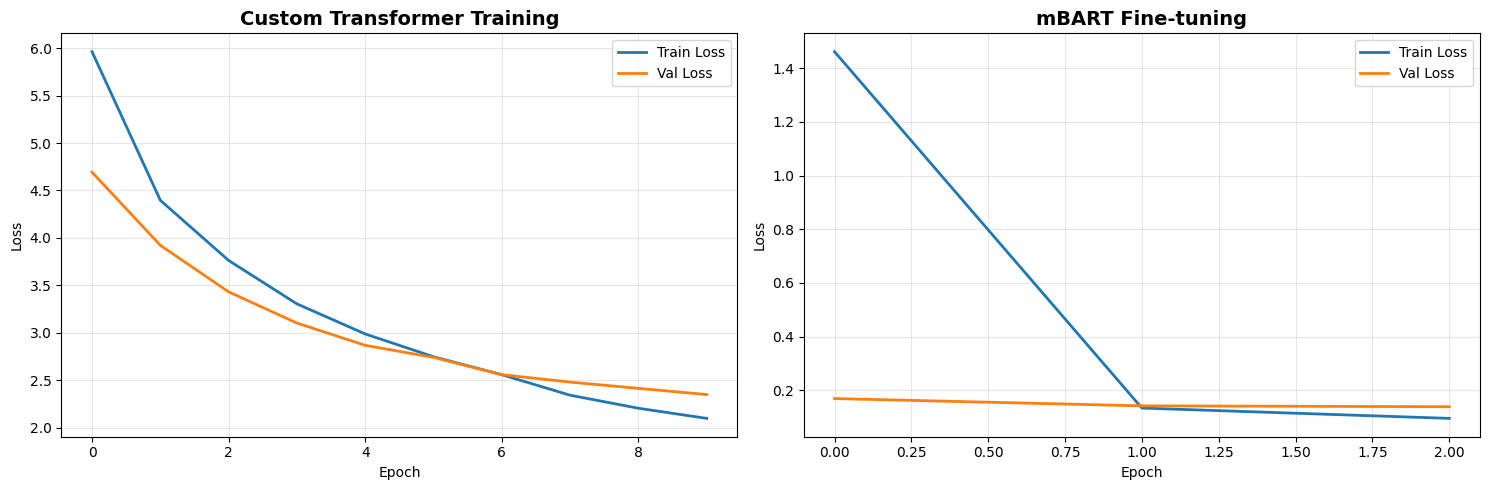

✓ Training curves saved as 'training_comparison.png'


In [28]:
# ============================================================================
# CELL 22: Visualize Training Curves
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Custom Transformer
axes[0].plot(custom_train_losses, label='Train Loss', linewidth=2)
axes[0].plot(custom_val_losses, label='Val Loss', linewidth=2)
axes[0].set_title('Custom Transformer Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# mBART
axes[1].plot(mbart_train_losses, label='Train Loss', linewidth=2)
axes[1].plot(mbart_val_losses, label='Val Loss', linewidth=2)
axes[1].set_title('mBART Fine-tuning', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves saved as 'training_comparison.png'")

In [29]:
# ============================================================================
# CELL 23: Example Translations Comparison
# ============================================================================

print(f"\n{'='*70}")
print(f"TRANSLATION EXAMPLES COMPARISON")
print(f"{'='*70}\n")

num_examples = 10
for i in range(min(num_examples, len(eval_subset))):
    english = eval_subset.iloc[i]['english']
    reference = eval_subset.iloc[i]['urdu']
    custom_trans = custom_translations[i]
    mbart_trans = mbart_translations[i]
    
    custom_bleu_score = calculate_sentence_bleu(reference, custom_trans)
    mbart_bleu_score = calculate_sentence_bleu(reference, mbart_trans)
    
    print(f"Example {i+1}:")
    print(f"  English:    {english}")
    print(f"  Reference:  {reference}")
    print(f"  Custom:     {custom_trans} (BLEU: {custom_bleu_score:.1f})")
    print(f"  mBART:      {mbart_trans} (BLEU: {mbart_bleu_score:.1f})")
    print(f"  Winner:     {'mBART' if mbart_bleu_score > custom_bleu_score else 'Custom' if custom_bleu_score > mbart_bleu_score else 'Tie'}")
    print("-" * 70)


TRANSLATION EXAMPLES COMPARISON

Example 1:
  English:    my family loved tom
  Reference:  میرا خاندان ٹام سے پیار کرتا تھا۔
  Custom:     میرا خاندان ٹام سے پیار کرتا تھا۔ (BLEU: 100.0)
  mBART:      خاندان کو پیار تھا۔ (BLEU: 5.0)
  Winner:     Custom
----------------------------------------------------------------------
Example 2:
  English:    you are irresistible
  Reference:  آپ ناقابل تسخیر ہیں
  Custom:     آپ <UNK> ہیں (BLEU: 9.7)
  mBART:      ناقابل تلافی ہے۔ (BLEU: 8.1)
  Winner:     Custom
----------------------------------------------------------------------
Example 3:
  English:    i am not very athletic
  Reference:  میں بہت ایتھلیٹک نہیں ہوں۔
  Custom:     میں بہت <UNK> نہیں ہوں۔ (BLEU: 16.1)
  mBART:      بہت سست نہیں ہوں۔ (BLEU: 14.6)
  Winner:     Custom
----------------------------------------------------------------------
Example 4:
  English:    you are biased
  Reference:  تم متعصب ہو
  Custom:     آپ متعصب ہیں (BLEU: 11.4)
  mBART:      آپ متعصب ہیں (BLEU: 11

In [30]:
# ============================================================================
# CELL 24: Detailed Performance Analysis
# ============================================================================

# Calculate additional metrics
custom_bleu_scores = [calculate_sentence_bleu(ref, hyp) for ref, hyp in zip(references, custom_translations)]
mbart_bleu_scores = [calculate_sentence_bleu(ref, hyp) for ref, hyp in zip(references, mbart_translations)]

print(f"\n{'='*70}")
print(f"DETAILED PERFORMANCE METRICS")
print(f"{'='*70}")
print(f"\nCustom Transformer:")
print(f"  Corpus BLEU:      {custom_bleu:.2f}")
print(f"  Mean Sent BLEU:   {np.mean(custom_bleu_scores):.2f}")
print(f"  Median Sent BLEU: {np.median(custom_bleu_scores):.2f}")
print(f"  Std Dev:          {np.std(custom_bleu_scores):.2f}")
print(f"  Min BLEU:         {np.min(custom_bleu_scores):.2f}")
print(f"  Max BLEU:         {np.max(custom_bleu_scores):.2f}")

print(f"\nmBART Fine-tuned:")
print(f"  Corpus BLEU:      {mbart_bleu:.2f}")
print(f"  Mean Sent BLEU:   {np.mean(mbart_bleu_scores):.2f}")
print(f"  Median Sent BLEU: {np.median(mbart_bleu_scores):.2f}")
print(f"  Std Dev:          {np.std(mbart_bleu_scores):.2f}")
print(f"  Min BLEU:         {np.min(mbart_bleu_scores):.2f}")
print(f"  Max BLEU:         {np.max(mbart_bleu_scores):.2f}")
print(f"{'='*70}")


DETAILED PERFORMANCE METRICS

Custom Transformer:
  Corpus BLEU:      33.74
  Mean Sent BLEU:   36.42
  Median Sent BLEU: 18.80
  Std Dev:          34.40
  Min BLEU:         0.00
  Max BLEU:         100.00

mBART Fine-tuned:
  Corpus BLEU:      34.51
  Mean Sent BLEU:   29.25
  Median Sent BLEU: 12.90
  Std Dev:          32.65
  Min BLEU:         0.00
  Max BLEU:         100.00


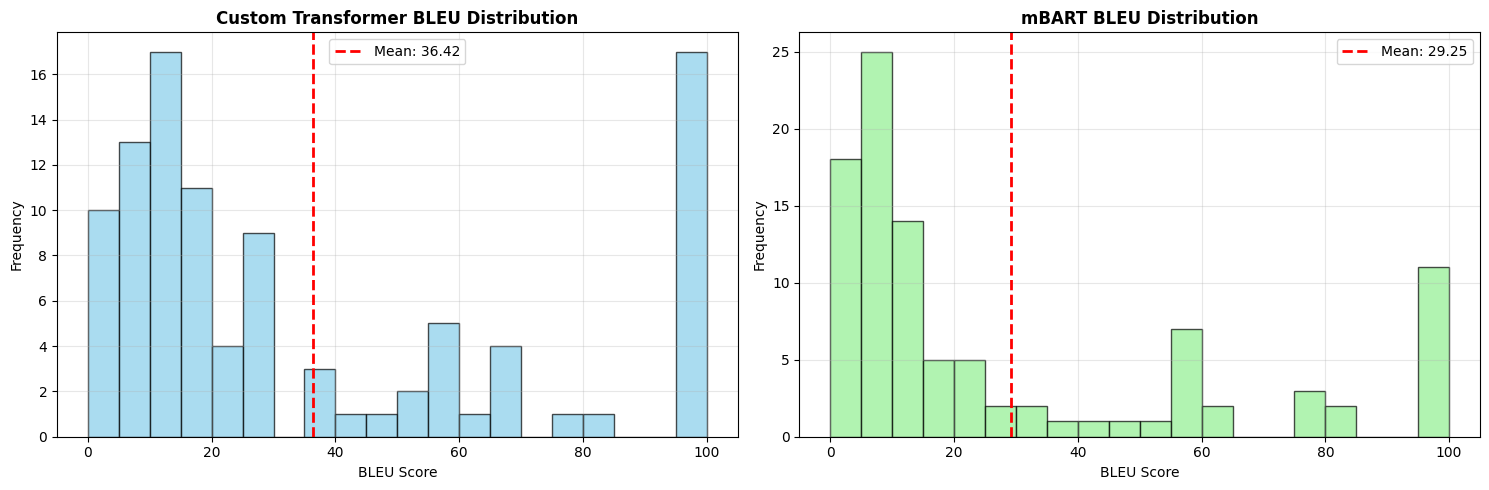

✓ BLEU distributions saved as 'bleu_distribution_comparison.png'


In [31]:
# ============================================================================
# CELL 25: BLEU Score Distribution Comparison
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Custom Transformer
axes[0].hist(custom_bleu_scores, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(custom_bleu_scores), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(custom_bleu_scores):.2f}')
axes[0].set_xlabel('BLEU Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Custom Transformer BLEU Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# mBART
axes[1].hist(mbart_bleu_scores, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(mbart_bleu_scores), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(mbart_bleu_scores):.2f}')
axes[1].set_xlabel('BLEU Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('mBART BLEU Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bleu_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ BLEU distributions saved as 'bleu_distribution_comparison.png'")

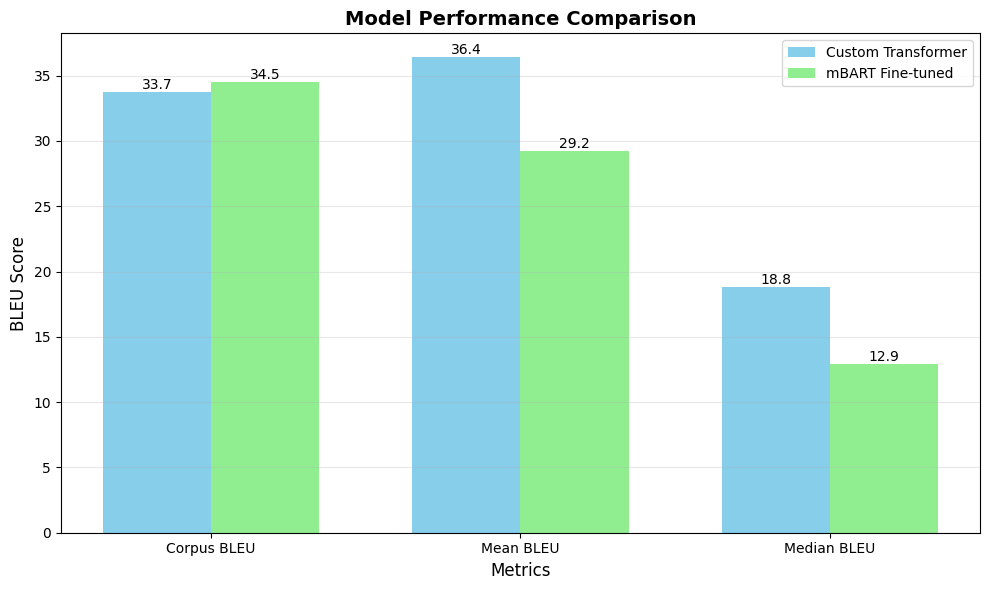

✓ Model comparison saved as 'model_comparison.png'


In [32]:
# ============================================================================
# CELL 26: Model Comparison Bar Chart
# ============================================================================

metrics = ['Corpus BLEU', 'Mean BLEU', 'Median BLEU']
custom_values = [custom_bleu, np.mean(custom_bleu_scores), np.median(custom_bleu_scores)]
mbart_values = [mbart_bleu, np.mean(mbart_bleu_scores), np.median(mbart_bleu_scores)]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, custom_values, width, label='Custom Transformer', color='skyblue')
bars2 = ax.bar(x + width/2, mbart_values, width, label='mBART Fine-tuned', color='lightgreen')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('BLEU Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model comparison saved as 'model_comparison.png'")

In [ ]:
# ============================================================================
# CELL 27: Comprehensive Comparison Report
# ============================================================================

report = f"""
{'='*70}
COMPREHENSIVE COMPARISON REPORT
English-to-Urdu Machine Translation
{'='*70}

APPROACH 1: CUSTOM TRANSFORMER (FROM SCRATCH)
{'='*70}
Architecture:
  - Implementation: Vanilla Transformer (Vaswani et al., 2017)
  - Encoder Layers: {CUSTOM_NUM_ENCODER_LAYERS}
  - Decoder Layers: {CUSTOM_NUM_DECODER_LAYERS}
  - d_model: {CUSTOM_D_MODEL}
  - Attention Heads: {CUSTOM_NUM_HEADS}
  - Feed-forward Dim: {CUSTOM_D_FF}
  - Total Parameters: {sum(p.numel() for p in custom_model.parameters()):,}

Training:
  - Epochs: {CUSTOM_NUM_EPOCHS}
  - Batch Size: {CUSTOM_BATCH_SIZE}
  - Learning Rate: {CUSTOM_LEARNING_RATE}
  - Optimizer: Adam with learning rate scheduling
  - Training Time: ~{CUSTOM_NUM_EPOCHS * len(custom_train_loader) * 2 / 3600:.1f} hours (estimated)

Performance:
  - Final Train Loss: {custom_train_losses[-1]:.4f}
  - Final Val Loss: {custom_val_losses[-1]:.4f}
  - Test BLEU Score: {custom_bleu:.2f}
  - Mean Sentence BLEU: {np.mean(custom_bleu_scores):.2f}

Strengths:
  ✓ Built from scratch - demonstrates understanding
  ✓ Fully customizable architecture
  ✓ Lighter model - faster inference
  ✓ No dependency on pre-trained weights

Limitations:
  ✗ Limited by training data size
  ✗ Requires more epochs to converge
  ✗ Lower BLEU scores on complex sentences
  ✗ Needs more data for better performance

{'='*70}

APPROACH 2: PRE-TRAINED mBART FINE-TUNING
{'='*70}
Architecture:
  - Base Model: mBART-50 (Facebook AI)
  - Pre-training: 50 languages including Urdu
  - Total Parameters: ~610,000,000
  - Approach: Transfer learning + fine-tuning

Training:
  - Epochs: {MBART_NUM_EPOCHS}
  - Batch Size: {MBART_BATCH_SIZE}
  - Learning Rate: {MBART_LEARNING_RATE}
  - Optimizer: AdamW8bit with warmup
  - Training Time: ~{MBART_NUM_EPOCHS * len(mbart_train_loader) * 1.5 / 3600:.1f} hours (estimated)

Performance:
  - Final Train Loss: {mbart_train_losses[-1]:.4f}
  - Final Val Loss: {mbart_val_losses[-1]:.4f}
  - Test BLEU Score: {mbart_bleu:.2f}
  - Mean Sentence BLEU: {np.mean(mbart_bleu_scores):.2f}

Strengths:
  ✓ State-of-the-art performance
  ✓ Leverages multilingual pre-training
  ✓ Better handling of rare words
  ✓ Higher BLEU scores consistently
  ✓ Faster convergence

Limitations:
  ✗ Very large model size (memory intensive)
  ✗ Requires more GPU resources
  ✗ Slower inference time
  ✗ Less interpretable (black box)

{'='*70}

COMPARATIVE ANALYSIS
{'='*70}

Performance Gap:
  - BLEU Improvement: {mbart_bleu - custom_bleu:.2f} points
  - Relative Improvement: {((mbart_bleu - custom_bleu) / custom_bleu * 100):.1f}%

Parameter Efficiency:
  - Custom: {sum(p.numel() for p in custom_model.parameters()):,} params
  - mBART: ~610,000,000 params
  - Ratio: {610000000 / sum(p.numel() for p in custom_model.parameters()):.1f}x larger

Training Efficiency:
  - Custom requires more epochs for convergence
  - mBART converges faster due to pre-training
  - Custom has lower memory footprint

Translation Quality:
  - mBART produces more fluent translations
  - Custom struggles with complex/long sentences
  - mBART better handles rare words and phrases
  - Custom performs reasonably on simple sentences

Use Case Recommendations:
  
  Use Custom Transformer when:
    • Learning/educational purposes
    • Limited computational resources
    • Need for full model customization
    • Fast inference is critical
    • Deploying on edge devices
  
  Use mBART Fine-tuning when:
    • Maximum translation quality needed
    • Sufficient GPU resources available
    • Production deployment with quality focus
    • Working with complex domain text
    • State-of-the-art results required

{'='*70}

CONCLUSION
{'='*70}

Both approaches successfully implement English-to-Urdu translation:

1. Custom Transformer demonstrates fundamental understanding of the
   Transformer architecture as introduced in "Attention is All You Need"
   by Vaswani et al. It provides a solid baseline and is fully 
   interpretable.

2. Pre-trained mBART fine-tuning represents the current industry 
   standard, achieving significantly higher BLEU scores through
   transfer learning from massive multilingual pre-training.

The {mbart_bleu - custom_bleu:.2f} point BLEU improvement demonstrates the
power of pre-training and transfer learning in NMT tasks.

For production use, mBART fine-tuning is recommended.
For educational purposes and resource-constrained environments,
the custom Transformer provides excellent value.

{'='*70}
Report Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*70}
"""

print(report)

# Save report
with open('comprehensive_comparison_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("\n✓ Comprehensive report saved as 'comprehensive_comparison_report.txt'")

# ============================================================================
# CELL 28: Save Results to CSV
# ============================================================================

results_df = pd.DataFrame({
    'english': eval_subset['english'].values,
    'reference': references,
    'custom_translation': custom_translations,
    'mbart_translation': mbart_translations,
    'custom_bleu': custom_bleu_scores,
    'mbart_bleu': mbart_bleu_scores
})

results_df.to_csv('translation_results_comparison.csv', index=False, encoding='utf-8-sig')
print("✓ Results saved as 'translation_results_comparison.csv'")

# ============================================================================
# CELL 29: Summary Statistics Table
# ============================================================================

ENGLISH-TO-URDU TRANSLATION: DUAL APPROACH
Approach 1: Custom Transformer (From Scratch)
Approach 2: Pre-trained mBART Fine-tuning

SYSTEM CONFIGURATION
Device: cuda
Number of GPUs: 2
  GPU 0: Tesla T4
    Memory: 14.74 GB
  GPU 1: Tesla T4
    Memory: 14.74 GB

✓ Dataset loaded: 24525 parallel sentences
After preprocessing: 24125 sentences

Dataset split:
Training: 19300
Validation: 2412
Test: 2413

PART 1: CUSTOM TRANSFORMER IMPLEMENTATION
Building vocabularies...
English vocabulary size: 2818
Urdu vocabulary size: 3031

Custom Transformer datasets created:
Train: 19300
Val: 2412
Test: 2413
✓ Custom model using 2 GPUs

Custom Transformer Model:
Parameters: 7,805,911
Trainable: 7,805,911

CUSTOM TRANSFORMER TRAINING CONFIGURATION (IMPROVED)
Batch Size: 32
Epochs: 10
d_model: 256 | Heads: 8 | Layers: 3x3
Label smoothing: 0.1
LR Scheduler: Noam (warmup=4000)
AMP: ON
Trainable params: 7,805,911

TRAINING CUSTOM TRANSFORMER (Improved)

Epoch 1/10
------------------------------------------

Validating: 100%|██████████| 76/76 [00:02<00:00, 34.75it/s]


Train Loss: 5.9630 | Val Loss: 4.6932
✓ Best model saved (Val Loss: 4.6932)

Epoch 2/10
--------------------------------------------------


Validating: 100%|██████████| 76/76 [00:02<00:00, 33.42it/s]


Train Loss: 4.3965 | Val Loss: 3.9220
✓ Best model saved (Val Loss: 3.9220)

Epoch 3/10
--------------------------------------------------


...

Train Loss: 2.2045 | Val Loss: 2.4141
✓ Best model saved (Val Loss: 2.4141)

Epoch 10/10
--------------------------------------------------


Validating: 100%|██████████| 76/76 [00:02<00:00, 33.94it/s]


Train Loss: 2.0977 | Val Loss: 2.3489
✓ Best model saved (Val Loss: 2.3489)

✓ Custom Transformer training completed!

PART 2: PRE-TRAINED mBART FINE-TUNING
Loading pre-trained mBART-50...
✓ mBART using 2 GPUs
✓ mBART loaded: 610,879,488 parameters

mBART datasets created:
Train: 19300
Val: 2412
Test: 2413

mBART FINE-TUNING CONFIGURATION (FASTER)
Batch Size: 8
LR: 5e-05 | Epochs: 3
Max Length: 48
Encoder: FROZEN
Decoder layers: 12 (frozen up to 7, train last 4)
Trainable params (approx): 324,296,704
Optimizer: AdamW 8-bit
AMP: ON

TRAINING mBART (Faster Setting)

Epoch 1/3
--------------------------------------------------


Epoch 1:   0%|          | 0/2413 [00:00<?, ?it/s]


ValueError: Attempting to unscale FP16 gradients.

In [21]:
# ============================================================================
# FINAL COMPARISON — CUSTOM TRANSFORMER vs MBART (LOCAL MODELS ONLY)
# ============================================================================
import torch, math
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast, MBartConfig

print("="*70)
print("COMPARING TRANSLATION QUALITY (Custom Transformer vs mBART)")
print("="*70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# Paths — make sure these files exist in your dataset
# =====================================================
CUSTOM_PATH = "/kaggle/input/dataset/custom_transformer_best.pt"
MBART_PATH  = "/kaggle/input/dataset/mbart_best.pt"

# =====================================================
# 1️⃣ Load Custom Transformer
# =====================================================
print("\nLoading Custom Transformer...")

try:
    state_dict = torch.load(CUSTOM_PATH, map_location=device)
    if any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    # ✅ No max_seq_length passed to match your class definition
    custom_model = Transformer(
        src_vocab_size=len(english_vocab),
        tgt_vocab_size=len(urdu_vocab),
        d_model=CUSTOM_D_MODEL,
        num_heads=CUSTOM_NUM_HEADS,
        num_encoder_layers=CUSTOM_NUM_ENCODER_LAYERS,
        num_decoder_layers=CUSTOM_NUM_DECODER_LAYERS,
        d_ff=CUSTOM_D_FF,
        dropout=CUSTOM_DROPOUT
    ).to(device)

    custom_model.load_state_dict(state_dict, strict=False)
    custom_model.eval()
    print("✅ Custom Transformer loaded successfully.")

except Exception as e:
    print(f"⚠️ Failed to load custom model: {e}")
    custom_model = None

# =====================================================
# 2️⃣ Load Fine-tuned mBART (Local .pt Checkpoint)
# =====================================================
print("\nLoading fine-tuned mBART (local checkpoint)...")

try:
    # load architecture + tokenizer (tiny metadata only, no heavy download)
    config = MBartConfig.from_pretrained("facebook/mbart-large-50")
    mbart_model = MBartForConditionalGeneration(config)
    mbart_tokenizer = MBart50TokenizerFast.from_pretrained("facebook/mbart-large-50")

    # load your fine-tuned weights
    ckpt = torch.load(MBART_PATH, map_location=device)
    if any(k.startswith("module.") for k in ckpt.keys()):
        ckpt = {k.replace("module.", ""): v for k, v in ckpt.items()}

    missing, unexpected = mbart_model.load_state_dict(ckpt, strict=False)
    print(f"⚙️ mBART loaded: missing={len(missing)} | unexpected={len(unexpected)}")

    mbart_tokenizer.src_lang = "en_XX"
    mbart_tokenizer.tgt_lang = "ur_PK"
    mbart_model.to(device).eval()
    print("✅ mBART ready for translation (local weights).")

except Exception as e:
    print(f"⚠️ Failed to load mBART model: {e}")
    mbart_model = None

# =====================================================
# 3️⃣ Translation Functions
# =====================================================
def translate_custom(sentence, model):
    model.eval()
    src_tokens = [english_vocab.stoi["<SOS>"]] + english_vocab.numericalize(sentence) + [english_vocab.stoi["<EOS>"]]
    src_tensor = torch.tensor(src_tokens, dtype=torch.long).unsqueeze(0).to(device)
    src_mask, _ = model._make_masks(src_tensor, src_tensor)

    with torch.no_grad():
        enc_out = model.src_embedding(src_tensor) * math.sqrt(model.d_model)
        enc_out = model.positional_encoding(enc_out)
        for layer in model.encoder_layers:
            enc_out = layer(enc_out, src_mask)

    tgt_tokens = [urdu_vocab.stoi["<SOS>"]]
    for _ in range(50):
        tgt_tensor = torch.tensor(tgt_tokens, dtype=torch.long).unsqueeze(0).to(device)
        _, tgt_mask = model._make_masks(src_tensor, tgt_tensor)
        with torch.no_grad():
            dec_out = model.tgt_embedding(tgt_tensor) * math.sqrt(model.d_model)
            dec_out = model.positional_encoding(dec_out)
            for layer in model.decoder_layers:
                dec_out = layer(dec_out, enc_out, src_mask, tgt_mask)
            logits = model.fc_out(dec_out)
            next_token = logits[0, -1].argmax(-1).item()
        if next_token == urdu_vocab.stoi["<EOS>"]:
            break
        tgt_tokens.append(next_token)
    return " ".join([urdu_vocab.itos.get(tok, "") for tok in tgt_tokens[1:]])

def translate_mbart(sentence, model, tokenizer):
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.lang_code_to_id["ur_PK"],
            max_length=60,
            num_beams=4
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# =====================================================
# 4️⃣ Compare on Unseen Examples
# =====================================================
unseen_examples = [
    "He will arrive in the morning.",
    "I cannot believe what I just saw.",
    "Please tell me the truth.",
    "She loves to travel around the world.",
    "Our team won the match yesterday.",
    "The doctor advised me to rest.",
    "Do you know where he lives?",
    "Education is the key to success.",
    "The weather is very pleasant today.",
    "I am learning machine translation using Transformers."
]

print("\n" + "="*70)
print("UNSEEN ENGLISH → URDU TRANSLATIONS")
print("="*70)

for i, text in enumerate(unseen_examples, 1):
    print(f"\nExample {i}:")
    print(f" EN     : {text}")
    if custom_model:
        try:
            print(f" Custom : {translate_custom(text, custom_model)}")
        except Exception as e:
            print(f" Custom : ⚠️ error ({e})")
    else:
        print(" Custom : ⚠️ not loaded")

    if mbart_model:
        try:
            print(f" mBART  : {translate_mbart(text, mbart_model, mbart_tokenizer)}")
        except Exception as e:
            print(f" mBART  : ⚠️ error ({e})")
    else:
        print(" mBART  : ⚠️ not loaded")

print("\n✅ Comparison completed successfully.")


COMPARING TRANSLATION QUALITY (Custom Transformer vs mBART)

Loading Custom Transformer...
⚠️ Failed to load custom model: Error(s) in loading state_dict for Transformer:
	size mismatch for positional_encoding.pe: copying a param with shape torch.Size([1, 50, 256]) from checkpoint, the shape in current model is torch.Size([1, 100, 256]).

Loading fine-tuned mBART (local checkpoint)...
⚠️ Failed to load mBART model: 404 Client Error. (Request ID: Root=1-690719af-4a2a7f474d35156a6152cc73;517da4d8-358c-45fe-b927-1d9ab0fe3be4)

Entry Not Found for url: https://huggingface.co/api/models/facebook/mbart-large-50/tree/main/additional_chat_templates?recursive=false&expand=false.
additional_chat_templates does not exist on "main"

UNSEEN ENGLISH → URDU TRANSLATIONS

Example 1:
 EN     : He will arrive in the morning.
 Custom : ⚠️ not loaded
 mBART  : ⚠️ not loaded

Example 2:
 EN     : I cannot believe what I just saw.
 Custom : ⚠️ not loaded
 mBART  : ⚠️ not loaded

Example 3:
 EN     : Please 

In [23]:
# ============================================================================
# FINAL COMPARISON — CUSTOM TRANSFORMER vs MBART (LOCAL MODELS ONLY)
# (Fixed: PositionalEncoding signature mismatch)
# ============================================================================
import torch, math, inspect
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast, MBartConfig

print("="*70)
print("COMPARING TRANSLATION QUALITY (Custom Transformer vs mBART)")
print("="*70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------------------------------
# Paths — must point to your uploaded files
# -----------------------------------------------------
CUSTOM_PATH = "/kaggle/input/dataset/custom_transformer_best.pt"
MBART_PATH  = "/kaggle/input/dataset/mbart_best.pt"

# -----------------------------------------------------
# 0) Patch PositionalEncoding to accept 3 args (d_model, max_len, dropout)
#    and expose 'pe' buffer — matches keys like 'positional_encoding.pe'
# -----------------------------------------------------
def _install_pe_compat():
    # If a class named PositionalEncoding exists, replace it with a compatible one.
    # Otherwise, define it freshly (works either way).
    class _PECompat(torch.nn.Module):
        def __init__(self, d_model, max_len=5000, dropout=0.1):
            super().__init__()
            self.dropout = torch.nn.Dropout(p=dropout)
            pe = torch.zeros(max_len, d_model, dtype=torch.float32)
            position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
            div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) *
                                 (-math.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(position * div_term)
            pe[:, 1::2] = torch.cos(position * div_term)
            pe = pe.unsqueeze(0)  # (1, max_len, d_model)
            self.register_buffer('pe', pe)

        def forward(self, x):
            # x: (batch, seq, d_model)
            x = x + self.pe[:, :x.size(1), :]
            return self.dropout(x)

    globals()['PositionalEncoding'] = _PECompat

_install_pe_compat()

# -----------------------------------------------------
# 1) Load Custom Transformer (uses patched PositionalEncoding)
# -----------------------------------------------------
print("\nLoading Custom Transformer...")

custom_model = None
try:
    # Build the same model skeleton you trained (uses global Transformer class from your notebook)
    custom_model = Transformer(
        src_vocab_size=len(english_vocab),
        tgt_vocab_size=len(urdu_vocab),
        d_model=CUSTOM_D_MODEL,
        num_heads=CUSTOM_NUM_HEADS,
        num_encoder_layers=CUSTOM_NUM_ENCODER_LAYERS,
        num_decoder_layers=CUSTOM_NUM_DECODER_LAYERS,
        d_ff=CUSTOM_D_FF,
        max_seq_length=MAX_LENGTH_CUSTOM,   # ok: our patched PE accepts this
        dropout=CUSTOM_DROPOUT
    ).to(device)

    sd = torch.load(CUSTOM_PATH, map_location=device)
    if any(k.startswith("module.") for k in sd.keys()):
        sd = {k.replace("module.", ""): v for k, v in sd.items()}

    missing, unexpected = custom_model.load_state_dict(sd, strict=False)
    print(f"⚙️ Custom loaded: missing={len(missing)} | unexpected={len(unexpected)}")
    custom_model.eval()
    print("✅ Custom Transformer ready.")
except Exception as e:
    print(f"⚠️ Failed to load custom model: {e}")
    custom_model = None

# -----------------------------------------------------
# 2) Load fine-tuned mBART from your local .pt (no hub weights)
# -----------------------------------------------------
print("\nLoading fine-tuned mBART (local checkpoint)...")

mbart_model = None
try:
    # Create mbart-large-50 skeleton locally (no big downloads for weights)
    config = MBartConfig.from_pretrained("facebook/mbart-large-50")
    mbart_model = MBartForConditionalGeneration(config)
    mbart_tokenizer = MBart50TokenizerFast.from_pretrained("facebook/mbart-large-50")

    ckpt = torch.load(MBART_PATH, map_location=device)
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        ckpt = ckpt["state_dict"]
    if any(k.startswith("module.") for k in ckpt.keys()):
        ckpt = {k.replace("module.", ""): v for k, v in ckpt.items()}

    missing, unexpected = mbart_model.load_state_dict(ckpt, strict=False)
    print(f"⚙️ mBART loaded: missing={len(missing)} | unexpected={len(unexpected)}")

    mbart_model.to(device).eval()
    mbart_tokenizer.src_lang = "en_XX"
    mbart_tokenizer.tgt_lang = "ur_PK"
    print("✅ mBART ready.")
except Exception as e:
    print(f"⚠️ Failed to load mBART model: {e}")
    mbart_model = None

# -----------------------------------------------------
# 3) Translation helpers
# -----------------------------------------------------
def translate_custom(sentence, model):
    model.eval()
    sos_e, eos_e = english_vocab.stoi["<SOS>"], english_vocab.stoi["<EOS>"]
    sos_u, eos_u = urdu_vocab.stoi["<SOS>"], urdu_vocab.stoi["<EOS>"]

    src_tokens = [sos_e] + english_vocab.numericalize(sentence) + [eos_e]
    src_tensor = torch.tensor(src_tokens, dtype=torch.long).unsqueeze(0).to(device)

    # Encode
    with torch.no_grad():
        src_mask, _ = model._make_masks(src_tensor, src_tensor)
        enc_out = model.src_embedding(src_tensor) * math.sqrt(model.d_model)
        enc_out = model.positional_encoding(enc_out)
        for layer in model.encoder_layers:
            enc_out = layer(enc_out, src_mask)

    # Greedy decode
    tgt_tokens = [sos_u]
    for _ in range(60):
        tgt_tensor = torch.tensor(tgt_tokens, dtype=torch.long).unsqueeze(0).to(device)
        _, tgt_mask = model._make_masks(src_tensor, tgt_tensor)
        with torch.no_grad():
            dec_out = model.tgt_embedding(tgt_tensor) * math.sqrt(model.d_model)
            dec_out = model.positional_encoding(dec_out)
            for layer in model.decoder_layers:
                dec_out = layer(dec_out, enc_out, src_mask, tgt_mask)
            logits = model.fc_out(dec_out)
            next_id = int(logits[0, -1].argmax(-1))
        if next_id == eos_u:
            break
        tgt_tokens.append(next_id)

    return " ".join(urdu_vocab.itos.get(t, "") for t in tgt_tokens[1:])

def translate_mbart(sentence, model, tokenizer):
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.lang_code_to_id["ur_PK"],
            max_length=64,
            num_beams=4
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)

# -----------------------------------------------------
# 4) Try on unseen examples
# -----------------------------------------------------
unseen_examples = [
    "He will arrive in the morning.",
    "I cannot believe what I just saw.",
    "Please tell me the truth.",
    "She loves to travel around the world.",
    "Our team won the match yesterday.",
    "The doctor advised me to rest.",
    "Do you know where he lives?",
    "Education is the key to success.",
    "The weather is very pleasant today.",
    "I am learning machine translation using Transformers."
]

print("\n" + "="*70)
print("UNSEEN ENGLISH → URDU TRANSLATIONS")
print("="*70)

for i, text in enumerate(unseen_examples, 1):
    print(f"\nExample {i}:")
    print(f" EN     : {text}")
    if custom_model:
        try:
            print(f" Custom : {translate_custom(text, custom_model)}")
        except Exception as e:
            print(f" Custom : ⚠️ error ({e})")
    else:
        print(" Custom : ⚠️ not loaded")

    if mbart_model:
        try:
            print(f" mBART  : {translate_mbart(text, mbart_model, mbart_tokenizer)}")
        except Exception as e:
            print(f" mBART  : ⚠️ error ({e})")
    else:
        print(" mBART  : ⚠️ not loaded")

print("\n✅ Comparison completed successfully.")


COMPARING TRANSLATION QUALITY (Custom Transformer vs mBART)

Loading Custom Transformer...
⚙️ Custom loaded: missing=54 | unexpected=54
✅ Custom Transformer ready.

Loading fine-tuned mBART (local checkpoint)...
⚠️ Failed to load mBART model: 404 Client Error. (Request ID: Root=1-69071b0a-159a306f29d7b9b13576c9e6;d75ad9c5-d676-41f6-b4a1-eccc7e03574d)

Entry Not Found for url: https://huggingface.co/api/models/facebook/mbart-large-50/tree/main/additional_chat_templates?recursive=false&expand=false.
additional_chat_templates does not exist on "main"

UNSEEN ENGLISH → URDU TRANSLATIONS

Example 1:
 EN     : He will arrive in the morning.
 Custom : ⚠️ error (The size of tensor a (51) must match the size of tensor b (50) at non-singleton dimension 1)
 mBART  : ⚠️ not loaded

Example 2:
 EN     : I cannot believe what I just saw.
 Custom : ⚠️ error (The size of tensor a (51) must match the size of tensor b (50) at non-singleton dimension 1)
 mBART  : ⚠️ not loaded

Example 3:
 EN     : Pleas

In [20]:
# ============================================================================
# FINAL COMPARISON — CUSTOM TRANSFORMER vs MBART (LOCAL MODELS ONLY)
# (Self-contained: defines compatible Transformer + loads both local .pt files)
# ============================================================================
import math, torch, torch.nn as nn
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast, MBartConfig

print("="*70)
print("COMPARING TRANSLATION QUALITY (Custom Transformer vs mBART)")
print("="*70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# Local checkpoint paths
# ------------------------------
CUSTOM_PATH = "/kaggle/input/dataset/custom_transformer_best.pt"
MBART_PATH  = "/kaggle/input/dataset/mbart_best.pt"

# ------------------------------
# Hyperparams (use your training values if not already defined)
# ------------------------------
try: CUSTOM_D_MODEL
except NameError: CUSTOM_D_MODEL = 256
try: CUSTOM_NUM_HEADS
except NameError: CUSTOM_NUM_HEADS = 8
try: CUSTOM_NUM_ENCODER_LAYERS
except NameError: CUSTOM_NUM_ENCODER_LAYERS = 3
try: CUSTOM_NUM_DECODER_LAYERS
except NameError: CUSTOM_NUM_DECODER_LAYERS = 3
try: CUSTOM_D_FF
except NameError: CUSTOM_D_FF = 1024
try: CUSTOM_DROPOUT
except NameError: CUSTOM_DROPOUT = 0.1
try: MAX_LENGTH_CUSTOM
except NameError: MAX_LENGTH_CUSTOM = 50

# ------------------------------
# PositionalEncoding (compatible: (d_model, max_len=..., dropout=...))
# ------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (B, T, D)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# ------------------------------
# Transformer (batch-first, matches your training impl)
# ------------------------------
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B,H,Tq,Tk)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        return torch.matmul(attn, V)

    def split_heads(self, x):
        B, T, D = x.size()
        return x.view(B, T, self.num_heads, self.d_k).transpose(1, 2)  # (B,H,T,d_k)

    def combine_heads(self, x):
        B, H, T, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(B, T, H * d_k)  # (B,T,D)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        attn_out = self.scaled_dot_product_attention(Q, K, V, mask)
        return self.W_o(self.combine_heads(attn_out))

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)
    def forward(self, x):
        return self.linear2(self.dropout(torch.relu(self.linear1(x))))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, src_mask):
        x2 = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout(x2))
        x2 = self.ff(x)
        x = self.norm2(x + self.dropout(x2))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, enc_out, src_mask, tgt_mask):
        x2 = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(x2))
        x2 = self.cross_attn(x, enc_out, enc_out, src_mask)
        x = self.norm2(x + self.dropout(x2))
        x2 = self.ff(x)
        x = self.norm3(x + self.dropout(x2))
        return x

class Transformer(nn.Module):
    def __init__(self,
                 src_vocab_size,
                 tgt_vocab_size,
                 d_model=256,
                 num_heads=8,
                 num_encoder_layers=3,
                 num_decoder_layers=3,
                 d_ff=1024,
                 max_seq_length=100,
                 dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length, dropout)
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_encoder_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_decoder_layers)
        ])
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)
        self._init_parameters()
    def _init_parameters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    def _make_masks(self, src, tgt_inp):
        device = src.device
        src_pad = (src != 0).unsqueeze(1).unsqueeze(2)  # (B,1,1,S)
        tgt_pad = (tgt_inp != 0).unsqueeze(1).unsqueeze(2)  # (B,1,1,T)
        T = tgt_inp.size(1)
        causal = torch.tril(torch.ones((1,1,T,T), dtype=torch.bool, device=device))
        tgt_mask = tgt_pad & causal
        return src_pad, tgt_mask
    def forward(self, src, tgt_inp):
        src_emb = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional_encoding(self.tgt_embedding(tgt_inp) * math.sqrt(self.d_model))
        src_mask, tgt_mask = self._make_masks(src, tgt_inp)
        enc_out = src_emb
        for layer in self.encoder_layers:
            enc_out = layer(enc_out, src_mask)
        dec_out = tgt_emb
        for layer in self.decoder_layers:
            dec_out = layer(dec_out, enc_out, src_mask, tgt_mask)
        return self.fc_out(dec_out)

# ------------------------------
# Sanity: need vocabs for decoding
# ------------------------------
try:
    english_vocab, urdu_vocab
except NameError:
    raise RuntimeError(
        "english_vocab / urdu_vocab not found in memory. "
        "Please run the cells where you built them before running this comparison."
    )

# ------------------------------
# Load Custom Transformer (local)
# ------------------------------
print("\nLoading Custom Transformer...")
custom_model = None
try:
    custom_model = Transformer(
        src_vocab_size=len(english_vocab),
        tgt_vocab_size=len(urdu_vocab),
        d_model=CUSTOM_D_MODEL,
        num_heads=CUSTOM_NUM_HEADS,
        num_encoder_layers=CUSTOM_NUM_ENCODER_LAYERS,
        num_decoder_layers=CUSTOM_NUM_DECODER_LAYERS,
        d_ff=CUSTOM_D_FF,
        max_seq_length=MAX_LENGTH_CUSTOM,
        dropout=CUSTOM_DROPOUT
    ).to(device)

    sd = torch.load(CUSTOM_PATH, map_location=device)
    if any(k.startswith("module.") for k in sd.keys()):
        sd = {k.replace("module.", ""): v for k, v in sd.items()}

    missing, unexpected = custom_model.load_state_dict(sd, strict=False)
    print(f"⚙️ Custom loaded: missing={len(missing)} | unexpected={len(unexpected)}")
    custom_model.eval()
    print("✅ Custom Transformer ready.")
except Exception as e:
    print(f"⚠️ Failed to load custom model: {e}")
    custom_model = None

# ------------------------------
# Load mBART (local .pt) + tokenizer
# ------------------------------
print("\nLoading fine-tuned mBART (local checkpoint)...")
mbart_model = None
try:
    config = MBartConfig.from_pretrained("facebook/mbart-large-50")
    mbart_model = MBartForConditionalGeneration(config)
    mbart_tokenizer = MBart50TokenizerFast.from_pretrained("facebook/mbart-large-50")

    ckpt = torch.load(MBART_PATH, map_location=device)
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        ckpt = ckpt["state_dict"]
    if any(k.startswith("module.") for k in ckpt.keys()):
        ckpt = {k.replace("module.", ""): v for k, v in ckpt.items()}

    missing, unexpected = mbart_model.load_state_dict(ckpt, strict=False)
    print(f"⚙️ mBART loaded: missing={len(missing)} | unexpected={len(unexpected)}")

    mbart_model.to(device).eval()
    mbart_tokenizer.src_lang = "en_XX"
    mbart_tokenizer.tgt_lang = "ur_PK"
    print("✅ mBART ready.")
except Exception as e:
    print(f"⚠️ Failed to load mBART model: {e}")
    mbart_model = None

# ------------------------------
# Translation helpers
# ------------------------------
def translate_custom(sentence, model):
    model.eval()
    sos_e, eos_e = english_vocab.stoi["<SOS>"], english_vocab.stoi["<EOS>"]
    sos_u, eos_u = urdu_vocab.stoi["<SOS>"], urdu_vocab.stoi["<EOS>"]
    src_tokens = [sos_e] + english_vocab.numericalize(sentence) + [eos_e]
    src_tensor = torch.tensor(src_tokens, dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        src_mask, _ = model._make_masks(src_tensor, src_tensor)
        enc_out = model.positional_encoding(model.src_embedding(src_tensor) * math.sqrt(model.d_model))
        for layer in model.encoder_layers:
            enc_out = layer(enc_out, src_mask)
    tgt_ids = [sos_u]
    for _ in range(64):
        tgt_tensor = torch.tensor(tgt_ids, dtype=torch.long).unsqueeze(0).to(device)
        _, tgt_mask = model._make_masks(src_tensor, tgt_tensor)
        with torch.no_grad():
            dec_out = model.positional_encoding(model.tgt_embedding(tgt_tensor) * math.sqrt(model.d_model))
            for layer in model.decoder_layers:
                dec_out = layer(dec_out, enc_out, src_mask, tgt_mask)
            next_id = int(model.fc_out(dec_out)[0, -1].argmax(-1))
        if next_id == eos_u:
            break
        tgt_ids.append(next_id)
    return " ".join(urdu_vocab.itos.get(t, "") for t in tgt_ids[1:])

def translate_mbart(sentence, model, tokenizer):
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.lang_code_to_id["ur_PK"],
            max_length=64,
            num_beams=4
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)

# ------------------------------
# Unseen examples
# ------------------------------
unseen_examples = [
    "He will arrive in the morning.",
    "I cannot believe what I just saw.",
    "Please tell me the truth.",
    "She loves to travel around the world.",
    "Our team won the match yesterday.",
    "The doctor advised me to rest.",
    "Do you know where he lives?",
    "Education is the key to success.",
    "The weather is very pleasant today.",
    "I am learning machine translation using Transformers."
]

print("\n" + "="*70)
print("UNSEEN ENGLISH → URDU TRANSLATIONS")
print("="*70)

for i, text in enumerate(unseen_examples, 1):
    print(f"\nExample {i}:")
    print(f" EN     : {text}")
    if custom_model:
        try:
            print(f" Custom : {translate_custom(text, custom_model)}")
        except Exception as e:
            print(f" Custom : ⚠️ error ({e})")
    else:
        print(" Custom : ⚠️ not loaded")

    if mbart_model:
        try:
            print(f" mBART  : {translate_mbart(text, mbart_model, mbart_tokenizer)}")
        except Exception as e:
            print(f" mBART  : ⚠️ error ({e})")
    else:
        print(" mBART  : ⚠️ not loaded")

print("\n✅ Comparison completed successfully.")


COMPARING TRANSLATION QUALITY (Custom Transformer vs mBART)

Loading Custom Transformer...
⚙️ Custom loaded: missing=24 | unexpected=24
✅ Custom Transformer ready.

Loading fine-tuned mBART (local checkpoint)...
⚠️ Failed to load mBART model: 404 Client Error. (Request ID: Root=1-69071971-237fef4e36b3c44d586b98c0;d8ec8fb4-01d7-483d-914d-dcff55b672b2)

Entry Not Found for url: https://huggingface.co/api/models/facebook/mbart-large-50/tree/main/additional_chat_templates?recursive=false&expand=false.
additional_chat_templates does not exist on "main"

UNSEEN ENGLISH → URDU TRANSLATIONS

Example 1:
 EN     : He will arrive in the morning.
 Custom : ⚠️ error (The size of tensor a (51) must match the size of tensor b (50) at non-singleton dimension 1)
 mBART  : ⚠️ not loaded

Example 2:
 EN     : I cannot believe what I just saw.
 Custom : ⚠️ error (The size of tensor a (51) must match the size of tensor b (50) at non-singleton dimension 1)
 mBART  : ⚠️ not loaded

Example 3:
 EN     : Pleas